In [4]:
import numpy as np
import matplotlib.pyplot as plt

from field_lines import PeriodicInterpolator, integrate_lines, unwrap_lines, plot_field_lines
from generate_goldreich_sridhar import get_aniso_cube, set_cubes

In [5]:
L = 300  # [pc], half-size
n_side = 256
dx = 2*L/n_side
k_min = 2*np.pi/(2*L)  # [pc-1], full wavelength in the cube
print(f"Each cell is a cube with size {dx:.2f} pc")
print(f"Injection scale corresponds to {2*np.pi/k_min:.2f} pc")

r_cube, _ = set_cubes(n_side, L)

Each cell is a cube with size 2.34 pc
Injection scale corresponds to 600.00 pc


In [6]:
b_cube = get_aniso_cube(n_side, L, k_min, model='YL02')

# Regular + turbulent field 

$$ B = \sqrt{B_0^2 + \langle{\delta B^2}\rangle} = B_0 \sqrt{1 + \eta^2}$$

This means,

$$ \mathbf{B} = \dfrac{\mathbf{B}_0 + \eta\,\mathbf{\delta B}}{\sqrt{1 + \eta^2}} = \dfrac{1}{\sqrt{1 + \eta^2}}\mathbf{B}_0 + \dfrac{\eta}{\sqrt{1 + \eta^2}}\mathbf{\delta B}, $$

where $\mathbf{B}_0$ and $\mathbf{\delta B}$ are normalized regular and turbulent magnetic fields, respectively.

## 0.1 turbulent / regular ratio

In [8]:
eta = 0.1

b0 = 1 / np.sqrt(1 + eta**2)

b_turb = eta / np.sqrt(1 + eta**2) * b_cube

b_cube_01 = b_turb
b_cube_01[2] += b0

In [9]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_01)

In [10]:
M = 50
ds = dx / 5
n_steps = int(1.5 * L / ds)  # n_steps

lines = integrate_lines(periodic_interpolator, M, n_steps, ds)
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

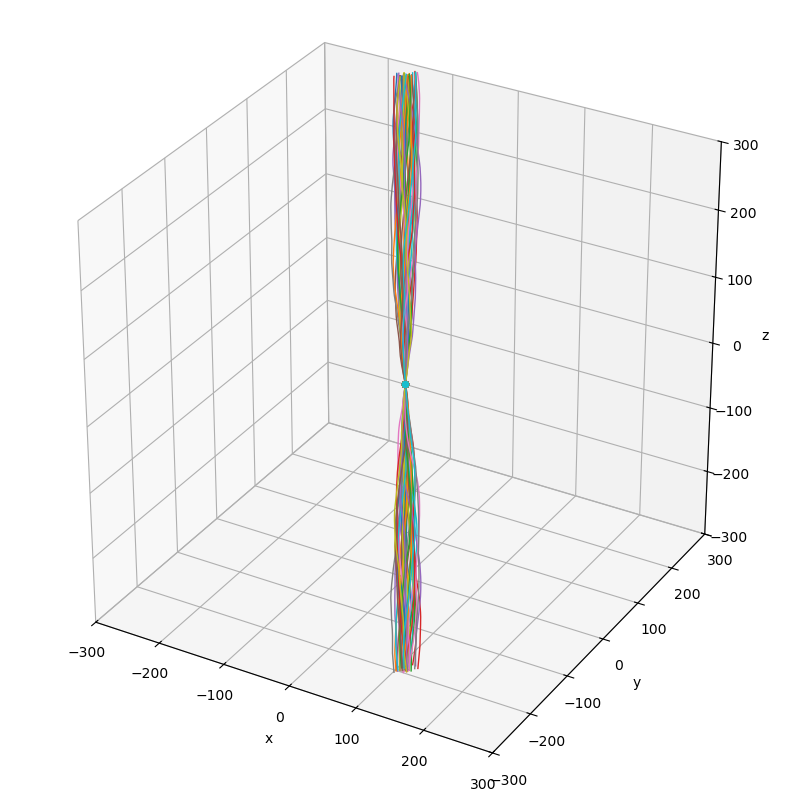

In [11]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

In [12]:
lengths = np.sqrt(np.sum(lines_from_zero**2, axis=2)) + 1e-32
cos01 = lines_from_zero[..., 2] / lengths

cos01_avg = np.average(cos01, axis=0)
cos01_std = np.std(np.abs(cos01), axis=0)

In [13]:
x = np.linspace(1, M, M)

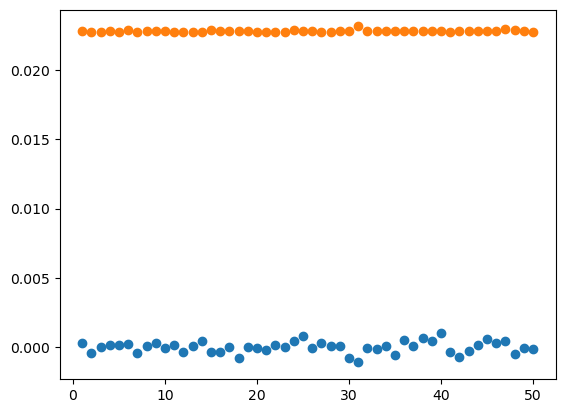

In [14]:
plt.scatter(x, cos01_avg)
plt.scatter(x, cos01_std)
plt.show()

## 0.5 turbulent / regular ratio

In [15]:
eta = 0.5

b0 = 1 / np.sqrt(1 + eta**2)

b_turb = eta / np.sqrt(1 + eta**2) * b_cube

b_cube_05 = b_turb
b_cube_05[2] += b0

In [16]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_05)

In [17]:
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

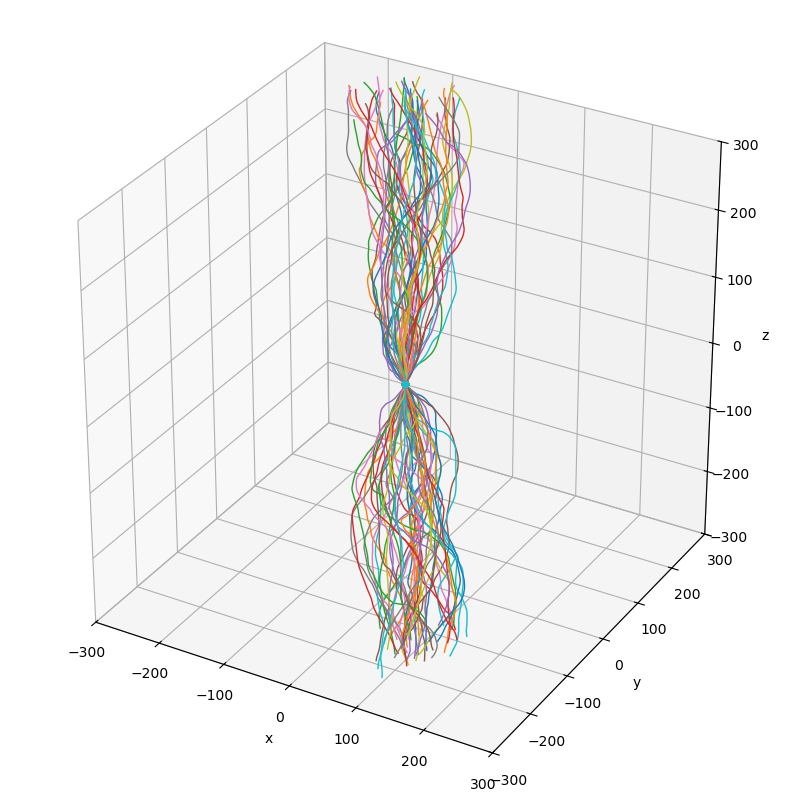

In [18]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

In [19]:
lengths = np.sqrt(np.sum(lines_from_zero**2, axis=2)) + 1e-32
cos05 = lines_from_zero[..., 2] / lengths

cos05_avg = np.average(cos05, axis=0)
cos05_std = np.std(np.abs(cos05), axis=0)

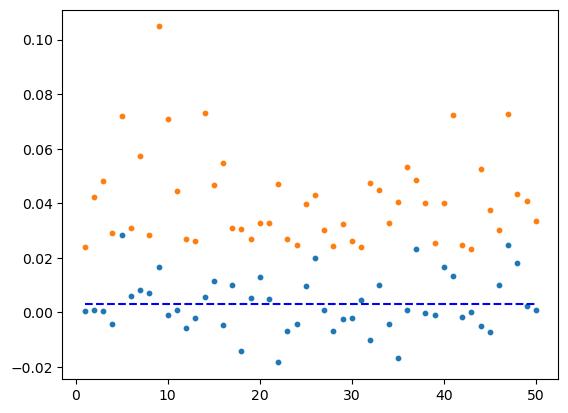

In [20]:
plt.scatter(x, cos05_avg, s=10)
plt.plot(x, np.ones_like(x) * np.mean(cos05_avg), color='blue', linestyle='dashed')
plt.scatter(x, cos05_std, s=10)
plt.show()

## 1.0 turbulent / regular ratio

In [21]:
eta = 1.0

b0 = 1 / np.sqrt(1 + eta**2)

b_turb = eta / np.sqrt(1 + eta**2) * b_cube

b_cube_10 = b_turb
b_cube_10[2] += b0

In [22]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_10)

In [23]:
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

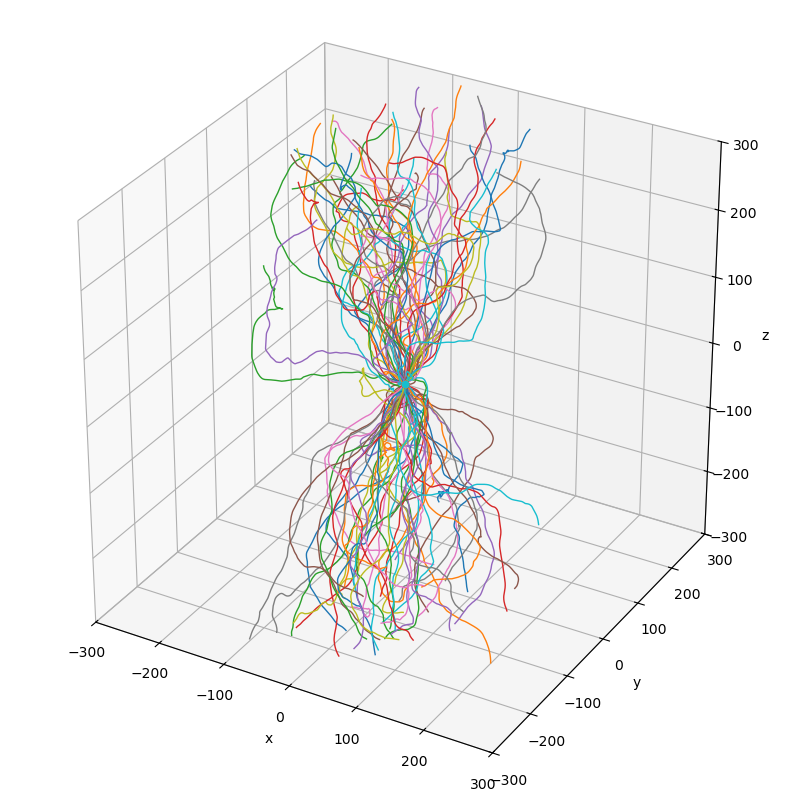

In [24]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

In [25]:
lengths = np.sqrt(np.sum(lines_from_zero**2, axis=2)) + 1e-32
cos10 = lines_from_zero[..., 2] / lengths

cos10_avg = np.average(cos10, axis=0)
cos10_std = np.std(np.abs(cos10), axis=0)

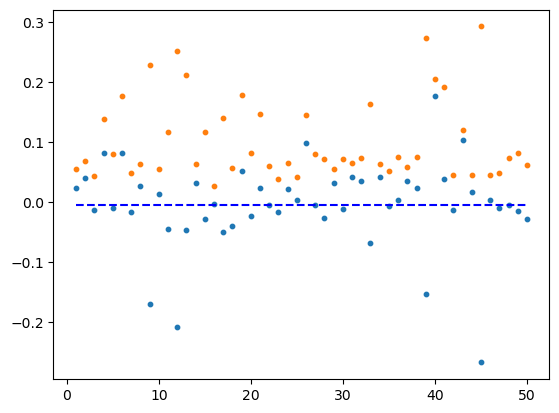

In [26]:
plt.scatter(x, cos10_avg, s=10)
plt.plot(x, np.ones_like(x) * np.mean(cos10_avg), color='blue', linestyle='dashed')
plt.scatter(x, cos10_std, s=10)
plt.show()